<a href="https://colab.research.google.com/github/RaisingEntropy/evolutionary_computation/blob/master/coevolution/coevolution_cooperative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cooperative Coevolution

In cooperative coevolution, individuals do not compete — they collaborate.

Instead of two opposing populations:
- We evolve multiple subcomponents of a solution
- Fitness depends on how well components work together

Key idea:
Individuals are evaluated as part of a team, not individually.

## Core Idea

- A solution is composed of multiple parts
- Each population evolves one part of the solution
- Fitness is based on the combined performance of these parts

This introduces:
- Credit assignment problem
- Interdependence between components

## Problem

We want to approximate a function:

$f(x) = 0.5 x^2 - 0.3 x + 0.4$

We will evolve a solution composed of two subcomponents:
- Component A
- Component B

Each population evolves parameters for one component.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

def target_function(x):
    return 0.5 * x**2 - 0.3 * x + 0.4

## Representation

We split the solution into two populations:

- Population A → controls parameters (a)
- Population B → controls parameters (b)

Each individual contributes part of the final function.

Final solution:
    f(x) = component_A(x) + component_B(x)

In [2]:
pop_size = 30
generations = 50

def init_population():
    return np.random.uniform(-1, 1, (pop_size, 3))  # each individual has 3 parameters

## Fitness Evaluation

Each individual is evaluated in combination with individuals from the other population.

We compute fitness by:
- Pairing individuals from both populations
- Evaluating the combined function
- Measuring error against the target function

In [24]:
def component_a(x, params):
    return params[0] * x * x + 0 * x + 0

def component_b(x, params):
    return 0 * x * x + params[1] * x + params[2]

def evaluate_pair(a, b, x_samples):
    preds = component_a(x_samples, a) + component_b(x_samples, b)
    return np.mean((preds - target_function(x_samples))**2)

def evaluate_population(popA, popB):
    fitnessA = np.zeros(len(popA))
    fitnessB = np.zeros(len(popB))

    x_samples = np.linspace(-5, 5, 50)

    for i, a in enumerate(popA):
        for b in popB:
            error = evaluate_pair(a, b, x_samples)
            fitnessA[i] += -error  # lower error is better
            fitnessB[np.where(popB == b)[0][0]] += -error

    return fitnessA, fitnessB

## Evolution Process

We evolve each population independently:

1. Evaluate individuals based on cooperation
2. Select the best individuals
3. Reproduce with mutation
4. Repeat

Important:
Fitness depends on partners from the other population

In [25]:
def select(pop, fitness):
    idx = np.argsort(fitness)[-len(pop)//2:]
    return pop[idx]

def reproduce(pop):
    children = []
    while len(children) <= pop_size:
        parent = random.choice(pop)
        child = parent + np.random.normal(0, 0.1, size=3)
        children.append(child)
    return np.array(children)

In [26]:
best_solutions = []

popA = init_population()
popB = init_population()

for gen in range(generations):
    fitA, fitB = evaluate_population(popA, popB)

    # Store best individuals
    best_a = popA[np.argmax(fitA)]
    best_b = popB[np.argmax(fitB)]
    best_solutions.append((gen, best_a, best_b))

    # Evolve
    popA = reproduce(select(popA, fitA))
    popB = reproduce(select(popB, fitB))

    print(f"Gen {gen}: Fitness A={fitA.mean():.3f}, Fitness B={fitB.mean():.3f}")

Gen 0: Fitness A=-2389.209, Fitness B=-2389.209
Gen 1: Fitness A=-245.344, Fitness B=-245.344
Gen 2: Fitness A=-65.030, Fitness B=-65.030
Gen 3: Fitness A=-73.817, Fitness B=-73.817
Gen 4: Fitness A=-47.614, Fitness B=-47.614
Gen 5: Fitness A=-73.663, Fitness B=-73.663
Gen 6: Fitness A=-59.373, Fitness B=-59.373
Gen 7: Fitness A=-62.186, Fitness B=-62.186
Gen 8: Fitness A=-59.911, Fitness B=-59.911
Gen 9: Fitness A=-51.083, Fitness B=-51.083
Gen 10: Fitness A=-44.016, Fitness B=-44.016
Gen 11: Fitness A=-50.114, Fitness B=-50.114
Gen 12: Fitness A=-30.011, Fitness B=-30.011
Gen 13: Fitness A=-47.401, Fitness B=-47.401
Gen 14: Fitness A=-71.965, Fitness B=-71.965
Gen 15: Fitness A=-63.242, Fitness B=-63.242
Gen 16: Fitness A=-60.425, Fitness B=-60.425
Gen 17: Fitness A=-46.393, Fitness B=-46.393
Gen 18: Fitness A=-50.260, Fitness B=-50.260
Gen 19: Fitness A=-47.944, Fitness B=-47.944
Gen 20: Fitness A=-50.881, Fitness B=-50.881
Gen 21: Fitness A=-44.003, Fitness B=-44.003
Gen 22: Fitnes

## Final Approximation

We can visualize how well the evolved solution approximates the target function.

In [27]:
x = np.linspace(-5, 5, 200)

ys = []
gens = []

for gen, a, b in best_solutions:
    y = component_a(x, a) + component_b(x, b)
    ys.append(y)
    gens.append(gen)

ys = np.array(ys)
gens = np.array(gens)

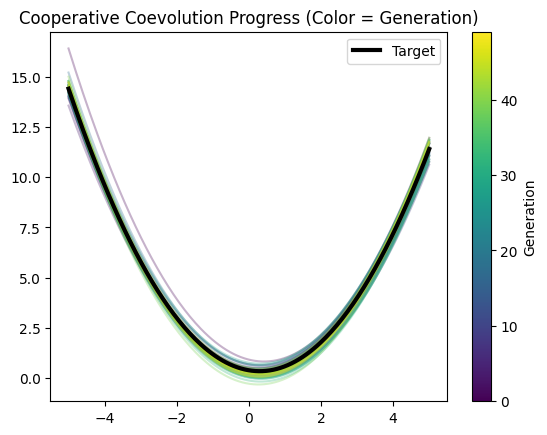

In [28]:
import matplotlib.cm as cm

fig, ax = plt.subplots()

norm = plt.Normalize(gens.min(), gens.max())
cmap = cm.viridis

for i in range(len(gens)):
    ax.plot(x, ys[i], color=cmap(norm(gens[i])), alpha=0.3)

# Plot target
ax.plot(x, target_function(x), color='black', linewidth=3, label="Target")

# Create scalar mappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Attach colorbar to the figure + axes
fig.colorbar(sm, ax=ax, label="Generation")

ax.set_title("Cooperative Coevolution Progress (Color = Generation)")
ax.legend()

plt.show()

## Exercise - Sensitivity to Decomposition

Goal: Show that decomposition matters.

Task:
- Population A models only the quadratic term
- Population B models only the linear + constant terms